# Chuẩn đoán bệnh tiểu đường

## 1. Định nghĩa vấn đề
+ **Mô tả :**
    + Bộ dữ liệu bao gồm 768 mẫu từ 768 hồ sơ của các bệnh nhân có hoặc không mẵ bệnh tiểu đường.
    + Mỗi mẫu bao gồm các đặc điểm vật lý (tuổi tác, số lần mang thai,..) và các đặc trưng sinh lý cơ thể (tỉ lệ BMI của cơ thể, mức đường huyết Glucozo, mức Insulin, ...).
+ **Dữ liệu đầu vào :**
    + `Pregnancies`: Số lần mang thai
    + `Glucose`: Mức đường huyết
    + `BloodPressure`: Huyết áp
    + `SkinThickness`: Độ dày da
    + `Insulin`: Mức insulin
    + `BMI`: Chỉ số khối cơ thể
    + `DiabetesPedigreeFunction`: Chỉ số di truyền tiểu đường
    + `Age`: Tuổi
+ **Kết quả :** Bệnh nhân có hoặc không mắc bệnh tiểu đường.

## 2. Chuẩn bị vấn đề.

### 2.1. Khai báo thư viện

In [80]:
import os, sys
from IPython import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline

warnings.filterwarnings("ignore")

### 2.2. Các tham số chương trình

In [81]:
seed = 42 # Random seed để khi chạy lại kết quả không thay đổi

exps_dir = "../exps"
if not os.path.exists(exps_dir):
    os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)

### 2.3. Nạp dữ liệu

In [82]:
data_path = "../data/pima.csv"
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(data_path, names=data_names)
display.display(data.head())
display.display(data.tail())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


### 2.4. Chia dữ liệu thực nghiệm
+ Dữ liệu ban đầu: Chia 7/3, 70% dùng để huấn luyện mô hình, 30% còn lại là tập Test
+ Dữ liệu huấn luyện: Chia theo chiến lược K-fold, k = 5

In [83]:
index_all = np.arange(768)
index_train, index_test = train_test_split(index_all, test_size=0.3, random_state=seed, shuffle=True)

In [84]:
df_train = data.iloc[index_train]
df_test = data.iloc[index_test]
print(f'Train : {len(df_train)}, Test : {len(df_test)} - Tỷ lệ: {len(df_train)/(len(data)):.2f} - {len(df_test)/(len(data)):.2f}')

Train : 537, Test : 231 - Tỷ lệ: 0.70 - 0.30


In [85]:
# Lưu lại dữ liệu sau khi chia
df_train.to_csv(f"{exps_dir}/data/train.csv", index=None)
df_test.to_csv(f"{exps_dir}/data/test.csv", index=None)
np.savez(f'{exps_dir}/data/idx.npz', index_train=index_train, index_test=index_test)

In [86]:
# Kiểm tra lại
dict(np.load(f'{exps_dir}/data/idx.npz'))

{'index_train': array([334, 139, 485, 547,  18, 593, 140, 326, 266, 626,  83,  61, 632,
        735,  29, 335, 599, 557, 311, 429, 182, 586, 679, 464, 223, 393,
        766, 570, 671, 412, 755, 176, 525, 333, 163, 248, 682,  74, 439,
        643, 104, 114, 749,  92, 380,  89, 417, 477, 713, 707, 506,  11,
         43,  42, 167, 675, 666, 381, 178, 705, 518, 177, 532, 539, 257,
        616, 440,  15, 478, 256, 388, 360, 367, 446, 589, 342, 453, 426,
          9, 249,  22, 221, 526, 751, 752, 424, 644, 203, 500,  93, 369,
        332, 522, 284, 184, 623, 365, 153,  75, 422, 277,  68, 695, 188,
        271, 236,  88, 654, 117, 125, 633, 289, 238,   0, 759, 368, 672,
        434, 278, 602, 116, 228, 545, 698, 533, 274, 318, 530, 144, 479,
        598, 696, 711, 268, 649, 307, 310, 420,  46, 349, 371, 595, 261,
        195, 767, 645, 107,  59, 578, 664, 100, 445, 689, 727, 423, 179,
        304, 398, 444, 739, 149, 124, 611, 669, 185, 674, 495, 436, 757,
        575, 321, 353, 709, 142, 724

In [87]:
# Đọc lại tập train
pd.read_csv(f"{exps_dir}/data/train.csv")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,95,60,18,58,23.9,0.260,22,0
1,5,105,72,29,325,36.9,0.159,28,0
2,0,135,68,42,250,42.3,0.365,24,1
3,4,131,68,21,166,33.1,0.160,28,0
4,1,103,30,38,83,43.3,0.183,33,0
...,...,...,...,...,...,...,...,...,...
532,5,139,64,35,140,28.6,0.411,26,0
533,1,96,122,0,0,22.4,0.207,27,0
534,10,101,86,37,0,45.6,1.136,38,1
535,0,141,0,0,0,42.4,0.205,29,1


## 3. Tiền xử lý dữ liệu

### 3.1. Làm sạch dữ liệu


+ Tạo bảng dữ liệu

In [88]:
df_train = pd.read_csv(f"{exps_dir}/data/train.csv")
df_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,95,60,18,58,23.9,0.260,22,0
1,5,105,72,29,325,36.9,0.159,28,0
2,0,135,68,42,250,42.3,0.365,24,1
3,4,131,68,21,166,33.1,0.160,28,0
4,1,103,30,38,83,43.3,0.183,33,0
...,...,...,...,...,...,...,...,...,...
532,5,139,64,35,140,28.6,0.411,26,0
533,1,96,122,0,0,22.4,0.207,27,0
534,10,101,86,37,0,45.6,1.136,38,1
535,0,141,0,0,0,42.4,0.205,29,1


+ Kiểm tra xem có mẫu dữ liệu bị trùng lặp không

In [89]:
display.display(df_train[df_train.duplicated(keep = False)])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


- Xử lí các cột có giá trị thiếu, không hợp lệ

In [90]:
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_train[zero_columns] = df_train[zero_columns].replace(0, np.nan)


In [91]:
print("==== Missing values ====")
display.display(df_train.isna().sum())

==== Missing values ====


Pregnancies                   0
Glucose                       5
BloodPressure                19
SkinThickness               154
Insulin                     261
BMI                           5
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [92]:
standard_cols = ['BMI', 'BloodPressure', 'Glucose']
skew_cols = ['Insulin', 'SkinThickness']
df_train[standard_cols] = df_train[standard_cols].fillna(df_train[standard_cols].mean())
df_train[skew_cols] = df_train[skew_cols].fillna(df_train[skew_cols].median())
print("==== Missing values after impute ====")
display.display(df_train.isna().sum())

==== Missing values after impute ====


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 3.2 Chuẩn hóa dữ liệu

Dùng hai cách để chuẩn hóa dữ liệu cơ bản để đưa về cùng miền giá trị là:
+ MinMax Normalization : 
$$ 
z = \frac{x - min(x)}{max(x) - min(x)}
$$
+ Standard Normalization :
$$
z = \frac{x - \mu}{\sigma}
$$

#### Min-Max Normalization : 

In [93]:
feature = df_train.drop(columns=["Outcome"])
scaler_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(df_train[scaler_columns])
# display.display(df_train)
df_minmax = df_train.copy()
df_minmax[scaler_columns] = minmax_scaler.transform(df_train[scaler_columns])
display.display(df_minmax)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.058824,0.329032,0.367347,0.181818,0.052885,0.116564,0.077711,0.016667,0
1,0.294118,0.393548,0.489796,0.381818,0.373798,0.382413,0.034586,0.116667,0
2,0.000000,0.587097,0.448980,0.618182,0.283654,0.492843,0.122545,0.050000,1
3,0.235294,0.561290,0.448980,0.236364,0.182692,0.304703,0.035013,0.116667,0
4,0.058824,0.380645,0.061224,0.545455,0.082933,0.513292,0.044833,0.200000,0
...,...,...,...,...,...,...,...,...,...
532,0.294118,0.612903,0.408163,0.490909,0.151442,0.212679,0.142186,0.083333,0
533,0.058824,0.335484,1.000000,0.381818,0.133413,0.085890,0.055081,0.100000,0
534,0.588235,0.367742,0.632653,0.527273,0.133413,0.560327,0.451751,0.283333,1
535,0.000000,0.625806,0.492258,0.381818,0.133413,0.494888,0.054227,0.133333,1


+ Xem các giá trị nội bộ sau khi dùng MinMaxScaler để fit dữ liệu

In [94]:
minmax_scaler.__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 537,
 'scale_': array([0.05882353, 0.00645161, 0.01020408, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.24489796, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 24.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  98.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

+ Lưu lại đối tượng minmax_scaler xuống thư mục lưu trữ

In [95]:
joblib.dump(minmax_scaler, f'{save_dir}/minmax_scaler.joblib')

['../exps/feature1/minmax_scaler.joblib']

+ Tải lên và kiểm tra lại các giá trị nội bộ sau khi lưu xuống có đúng hay không

In [96]:
joblib.load(f'{save_dir}/minmax_scaler.joblib').__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 537,
 'scale_': array([0.05882353, 0.00645161, 0.01020408, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.24489796, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 24.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  98.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

+ Lưu danh sách các cột đã được chuẩn hóa vào file.npz của Numpy

In [97]:
np.savez(f'{save_dir}/scale_columns.npz', columns = scaler_columns)
dict(np.load(f'{save_dir}/scale_columns.npz'))

{'columns': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='<U24')}

+ Biểu đồ BoxPlot biểu diễn giá trị các cột sau khi chuẩn hóa dữ liệu

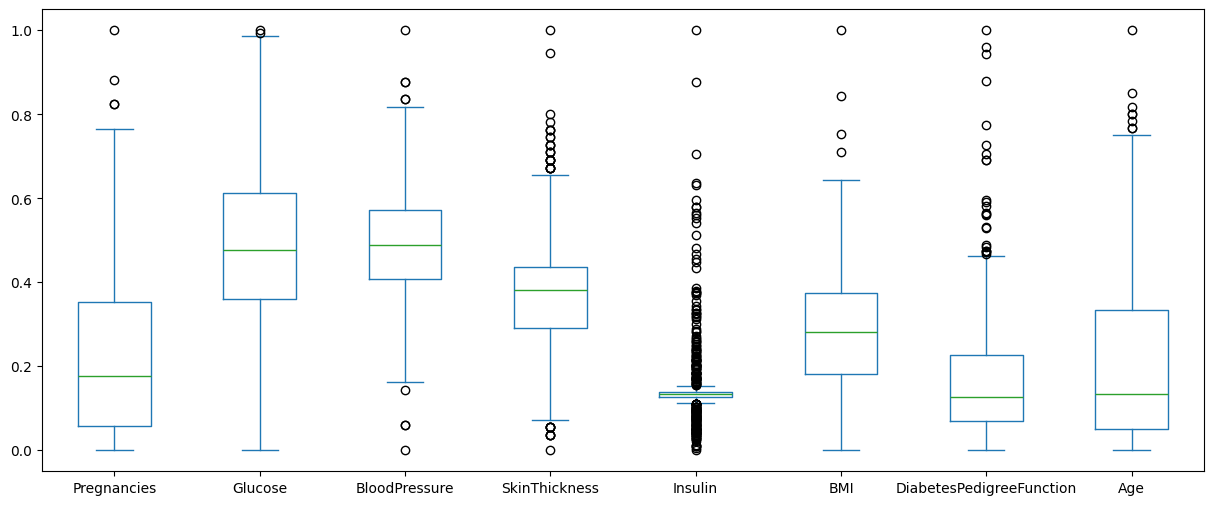

In [98]:
df_minmax[scaler_columns].plot(kind = 'box', figsize=(15, 6));

#### Standard Normalization

In [109]:
standard_scaler = StandardScaler()
standard_scaler.fit(df_train[scaler_columns])
df_standard = df_train.copy()
df_standard[scaler_columns] = standard_scaler.transform(df_train[scaler_columns])
display.display(df_standard)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.836294,-0.896201,-1.003928,-1.269545,-1.567398,-1.203794,-0.614216,-0.948610,0
1,0.390728,-0.564089,-0.019790,0.029693,1.987863,0.664530,-0.909738,-0.434667,0
2,-1.143050,0.432244,-0.347836,1.565156,1.444090,1.440603,-0.306991,-0.777296,1
3,0.083972,0.299399,-0.347836,-0.915207,0.596624,0.118405,-0.906812,-0.434667,0
4,-0.836294,-0.630512,-3.464272,1.092706,-0.832620,1.584320,-0.839515,-0.006380,0
...,...,...,...,...,...,...,...,...,...
532,0.390728,0.565088,-0.675882,0.738368,0.244639,-0.528323,-0.172397,-0.605981,0
533,-0.836294,-0.862989,4.080783,0.029693,0.010698,-1.419369,-0.769292,-0.520324,0
534,1.924505,-0.696934,1.128370,0.974593,0.010698,1.914870,1.948921,0.421906,1
535,-1.143050,0.631510,0.000000,0.029693,0.010698,1.454975,-0.775144,-0.349009,1


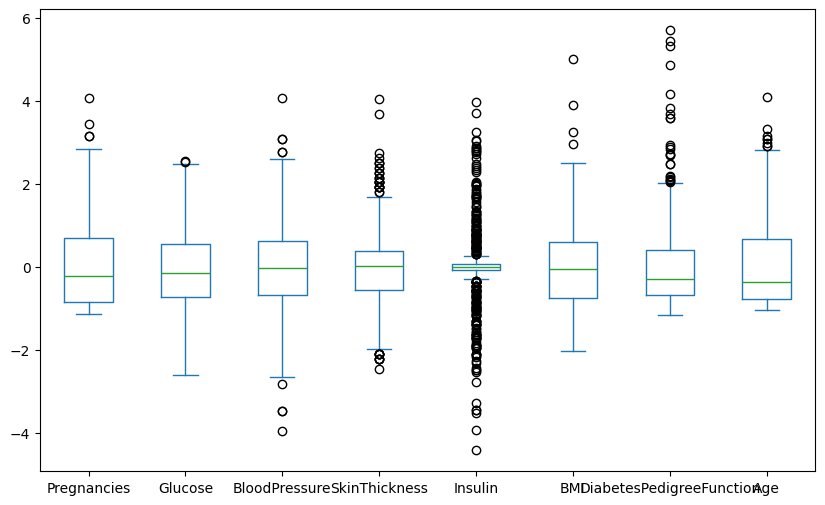

In [110]:
df_standard[scaler_columns].plot(kind='box', figsize=(10, 6));

In [101]:
corr = df_train.corr(method='pearson')
display.display(corr)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.137693,0.187694,0.095474,0.030122,0.034819,-0.022582,0.544940,0.196957
Glucose,0.137693,1.000000,0.212747,0.131047,0.416088,0.237688,0.171067,0.273108,0.517430
BloodPressure,0.187694,0.212747,1.000000,0.187475,0.021125,0.244629,0.022688,0.336085,0.174597
SkinThickness,0.095474,0.131047,0.187475,1.000000,0.113274,0.579059,0.127308,0.110442,0.212693
Insulin,0.030122,0.416088,0.021125,0.113274,1.000000,0.134176,0.121976,0.111828,0.217950
BMI,0.034819,0.237688,0.244629,0.579059,0.134176,1.000000,0.170522,0.027989,0.340774
DiabetesPedigreeFunction,-0.022582,0.171067,0.022688,0.127308,0.121976,0.170522,1.000000,0.033531,0.148887
Age,0.544940,0.273108,0.336085,0.110442,0.111828,0.027989,0.033531,1.000000,0.279896
Outcome,0.196957,0.517430,0.174597,0.212693,0.217950,0.340774,0.148887,0.279896,1.000000


In [102]:
standard_scaler.__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': np.int64(537),
 'mean_': array([  3.72625698, 121.98496241,  72.24131274,  28.74860335,
        140.59031657,  32.27612782,   0.46991993,  33.0744879 ]),
 'var_': array([1.06271132e+01, 9.06636647e+02, 1.48679396e+02, 7.16816787e+01,
        7.44801838e+03, 4.84152827e+01, 1.16805843e-01, 1.36292403e+02]),
 'scale_': array([ 3.25992533, 30.11040763, 12.19341611,  8.46650333, 86.30190252,
         6.95810913,  0.3417687 , 11.67443374])}

In [103]:
joblib.dump(standard_scaler, f'{save_dir}/standard_scaler.joblib')

['../exps/feature1/standard_scaler.joblib']

In [104]:
joblib.load(f'{save_dir}/standard_scaler.joblib').__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': np.int64(537),
 'mean_': array([  3.72625698, 121.98496241,  72.24131274,  28.74860335,
        140.59031657,  32.27612782,   0.46991993,  33.0744879 ]),
 'var_': array([1.06271132e+01, 9.06636647e+02, 1.48679396e+02, 7.16816787e+01,
        7.44801838e+03, 4.84152827e+01, 1.16805843e-01, 1.36292403e+02]),
 'scale_': array([ 3.25992533, 30.11040763, 12.19341611,  8.46650333, 86.30190252,
         6.95810913,  0.3417687 , 11.67443374])}

#### Lưu dữ liệu feature
- Lưu dữ liệu ở dạng Numpy array với phần input (x_train), output (y_train)
- Lưu tất cả thông tin ở dang Excel để xem và phân tích

In [105]:
## minmax
x_train = df_minmax.values[:,:-1]
y_train = df_minmax.values[:,-1]
display.display(df_minmax.head())

print("x_train: \n ", x_train[:5, :])
print("y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_minmax.npz', x_train=x_train, y_train=y_train)
df_minmax.to_excel(f'{save_dir}/df_minmax.xlsx', index=False)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.058824,0.329032,0.367347,0.181818,0.052885,0.116564,0.077711,0.016667,0
1,0.294118,0.393548,0.489796,0.381818,0.373798,0.382413,0.034586,0.116667,0
2,0.000000,0.587097,0.448980,0.618182,0.283654,0.492843,0.122545,0.050000,1
3,0.235294,0.561290,0.448980,0.236364,0.182692,0.304703,0.035013,0.116667,0
4,0.058824,0.380645,0.061224,0.545455,0.082933,0.513292,0.044833,0.200000,0


x_train: 
  [[0.05882353 0.32903226 0.36734694 0.18181818 0.05288462 0.11656442
  0.07771136 0.01666667]
 [0.29411765 0.39354839 0.48979592 0.38181818 0.37379808 0.38241309
  0.03458582 0.11666667]
 [0.         0.58709677 0.44897959 0.61818182 0.28365385 0.49284254
  0.12254483 0.05      ]
 [0.23529412 0.56129032 0.44897959 0.23636364 0.18269231 0.30470348
  0.03501281 0.11666667]
 [0.05882353 0.38064516 0.06122449 0.54545455 0.08293269 0.51329243
  0.04483348 0.2       ]]
y_train: 
  [0. 0. 1. 0. 0.]


In [106]:
# standard 
x_train = df_standard.values[:,:-1]
y_train = df_standard.values[:,-1]
display.display(df_standard.head())

print("x_train: \n ", x_train[:5, :])
print("y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_standard.npz', x_train=x_train, y_train=y_train)
df_standard.to_excel(f'{save_dir}/df_standard.xlsx', index=False)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.836294,-0.896201,-1.003928,-1.269545,-0.956993,-1.203794,-0.614216,-0.948610,0
1,0.390728,-0.564089,-0.019790,0.029693,2.136797,0.664530,-0.909738,-0.434667,0
2,-1.143050,0.432244,-0.347836,1.565156,1.267755,1.440603,-0.306991,-0.777296,1
3,0.083972,0.299399,-0.347836,-0.915207,0.294428,0.118405,-0.906812,-0.434667,0
4,-0.836294,-0.630512,-3.464272,1.092706,-0.667312,1.584320,-0.839515,-0.006380,0


x_train: 
  [[-0.8362943  -0.8962005  -1.00392807 -1.26954457 -0.956993   -1.20379368
  -0.61421636 -0.94861028]
 [ 0.39072767 -0.56408942 -0.01979041  0.02969309  2.13679743  0.66452999
  -0.90973787 -0.43466673]
 [-1.14304979  0.43224382 -0.3478363   1.56515578  1.26775517  1.4406029
  -0.30699103 -0.77729576]
 [ 0.08397217  0.29939939 -0.3478363  -0.91520703  0.29442785  0.11840461
  -0.90681191 -0.43466673]
 [-0.8362943  -0.63051164 -3.46427222  1.09270572 -0.66731225  1.5843201
  -0.83951493 -0.00638043]]
y_train: 
  [0. 0. 1. 0. 0.]


# Kết thúc